<div style="background:linear-gradient(135deg,#0D2B55 0%,#1F497D 60%,#2E86C1 100%);padding:28px 32px;border-radius:10px;margin-bottom:18px"><h1 style="color:white;margin:0 0 6px 0;font-size:1.9em">Session 9: Factor Models &amp; Event Studies</h1><p style="color:#BDC3C7;margin:0;font-size:1.0em">Aarhus Summer University · July 2026</p><p style="color:#85C1E9;margin:8px 0 0 0;font-size:0.9em">CAPM · Fama-French 3-Factor </p></div>

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas_datareader.data as web
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (12, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12,
})

# Analysis period — matches CAPM/FF3F slides
START = '2021-05-16'
END   = '2026-05-15'

# ── Risk-free rate: 3-month T-bill (TB3MS) from FRED ───────────────────────
# TB3MS is reported monthly as an annualised percentage; convert to daily decimal
try:
    _tb3ms = web.DataReader('TB3MS', 'fred', start=START, end=END)['TB3MS']
    rf_ts  = (_tb3ms / 100 / 252).resample('B').ffill()   # daily business-day grid
    rf_ts.index = rf_ts.index.tz_localize(None)           # strip timezone for alignment
    RF_DAILY = float(rf_ts.mean())                        # period average (scalar fallback)
    print(f'TB3MS loaded: avg {RF_DAILY*252:.2%}/yr | '
          f'range {rf_ts.min()*252:.2%}–{rf_ts.max()*252:.2%}/yr | '
          f'{len(rf_ts):,} daily obs')
except Exception as _e:
    rf_ts    = None
    RF_DAILY = 0.04 / 252
    print(f'FRED unavailable ({_e}) — using constant RF = {RF_DAILY*252:.1%}/yr')

# ── Equity returns ─────────────────────────────────────────────────────────
print('Downloading AAPL and SPY...')
aapl_px  = yf.download('AAPL', start=START, end=END,
                        auto_adjust=True, progress=False)['Close'].squeeze()
spy_px   = yf.download('SPY',  start=START, end=END,
                        auto_adjust=True, progress=False)['Close'].squeeze()

aapl_ret = aapl_px.pct_change().dropna()
spy_ret  = spy_px.pct_change().dropna()

print(f'AAPL: {len(aapl_ret):,} trading days | '
      f'mean: {aapl_ret.mean():.4%}/day | '
      f'ann. vol: {aapl_ret.std()*np.sqrt(252):.2%}')
print(f'SPY:  {len(spy_ret):,} trading days  | '
      f'mean: {spy_ret.mean():.4%}/day | '
      f'ann. vol: {spy_ret.std()*np.sqrt(252):.2%}')


TB3MS loaded: avg 3.53%/yr | range 0.04%–5.34%/yr | 1,262 daily obs


AAPL: 1,254 trading days | mean: 0.0855%/day | ann. vol: 27.45%
SPY:  1,254 trading days  | mean: 0.0581%/day | ann. vol: 17.05%


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">CAPM & Factor Models</span><br><span style="color:#BDC3C7;font-size:0.93em">Why factor models · CAPM theory · Alpha & Beta · Market model</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Why Factor Models — The Central Question of Asset Pricing</div>

**Central question:** why do different assets earn different average returns?

**Factor model decomposition:**

$$\text{Return} = R_f + \sum_k \beta_k \cdot F_k + \alpha + \varepsilon$$

- $F_k$ — systematic risk factors (market, size, value, …)
- $\beta_k$ — factor loadings (sensitivities)
- $\alpha$ — unexplained excess return (manager skill or mispricing)
- $\varepsilon$ — idiosyncratic noise (diversified away in a portfolio)

> **Key insight:** alpha is only meaningful after controlling for all relevant factors.
> Raw return is not alpha if it comes from known risk exposures.

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">CAPM — The Capital Asset Pricing Model</div>

**Sharpe (1964), Lintner (1965):** the first formal equilibrium theory of expected return.

$$E(R_i) = R_f + \beta_i \cdot [E(R_m) - R_f]$$

**Jensen's alpha regression form:**

$$R_i - R_f = \alpha_i + \beta_i (R_m - R_f) + \varepsilon_i$$

Run this OLS regression in Python:
- $\alpha$ is the intercept — should be zero if CAPM holds exactly
- $\beta$ is the slope — measures systematic market risk
- $R^2$ — fraction of asset return variance explained by the market

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">CAPM Regression in Python — OLS with statsmodels</div>

In [2]:
# Strip timezone from yfinance returns so they align with FRED dates (tz-naive)
aapl_ntz_capm = aapl_ret.copy()
spy_ntz_capm  = spy_ret.copy()
if getattr(aapl_ntz_capm.index, 'tz', None) is not None:
    aapl_ntz_capm.index = aapl_ntz_capm.index.tz_localize(None)
if getattr(spy_ntz_capm.index, 'tz', None) is not None:
    spy_ntz_capm.index  = spy_ntz_capm.index.tz_localize(None)

# Excess returns — time-varying TB3MS (or scalar fallback if FRED unavailable)
rf_aligned = (
    rf_ts.reindex(aapl_ntz_capm.index, method='ffill').fillna(RF_DAILY)
    if rf_ts is not None else RF_DAILY
)
ri = aapl_ntz_capm - rf_aligned
rm = spy_ntz_capm  - rf_aligned

df_capm = pd.DataFrame({'ri': ri, 'rm': rm}).dropna()

# OLS: (Ri - Rf) = alpha + beta*(Rm - Rf) + epsilon
X_capm   = sm.add_constant(df_capm['rm'])
res_capm = sm.OLS(df_capm['ri'], X_capm).fit()

alpha_capm = res_capm.params['const']
beta_capm  = res_capm.params['rm']
r2_capm    = res_capm.rsquared

print(f'CAPM Results — AAPL vs SPY ({START} to {END})')
print(f'  Alpha : {alpha_capm*252:+.2%}/yr  (p = {res_capm.pvalues["const"]:.3f})')
print(f'  Beta  : {beta_capm:.4f}')
print(f'  R²    : {r2_capm:.4f}')
print(f'  Resid std: {res_capm.resid.std()*np.sqrt(252):.2%}/yr (idiosyncratic vol)')


CAPM Results — AAPL vs SPY (2021-05-16 to 2026-05-15)
  Alpha : +4.53%/yr  (p = 0.576)
  Beta  : 1.2125
  R²    : 0.5670
  Resid std: 18.07%/yr (idiosyncratic vol)


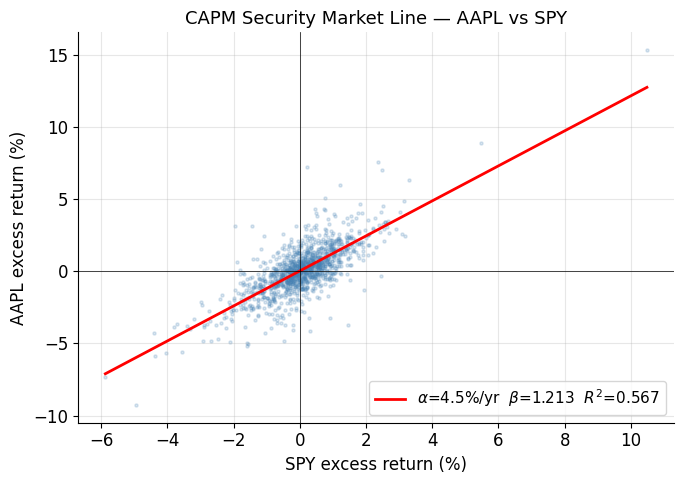

In [3]:
# Scatter plot: AAPL excess return vs SPY excess return
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_capm['rm']*100, df_capm['ri']*100,
           alpha=0.2, s=5, color='steelblue')

# Regression line
x_line = np.linspace(df_capm['rm'].min(), df_capm['rm'].max(), 200)
y_line = alpha_capm + beta_capm * x_line
ax.plot(x_line*100, y_line*100, 'r-', linewidth=2,
        label=fr'$\alpha$={alpha_capm*252:.1%}/yr  $\beta$={beta_capm:.3f}  $R^2$={r2_capm:.3f}')

ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('SPY excess return (%)')
ax.set_ylabel('AAPL excess return (%)')
ax.set_title('CAPM Security Market Line — AAPL vs SPY', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Alpha & Beta Interpretation + Rolling Beta</div>

<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> Beta is not constant over time. Rolling estimates reveal regime changes: AAPL's beta typically rises during market stress (2020 COVID, 2022 rate shock) and falls during low-volatility bull markets.</div>

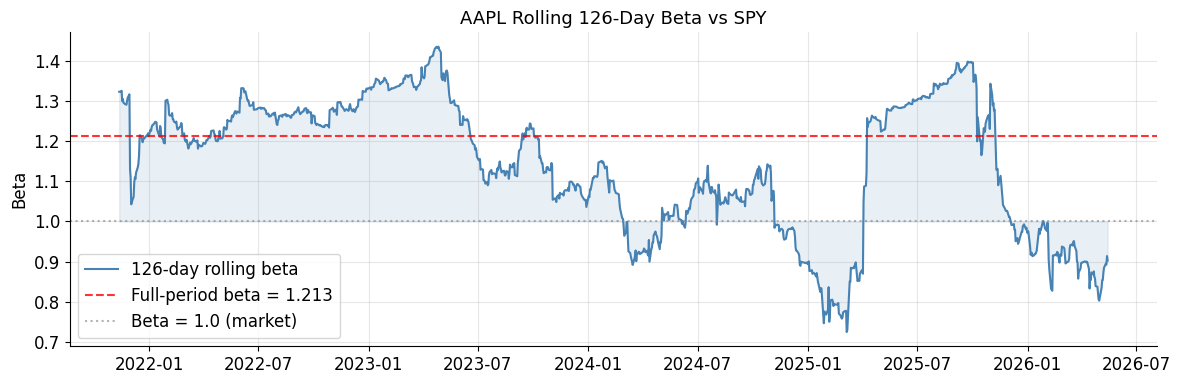

Beta range: 0.724 – 1.436
Beta > 1.5 on 0 trading days


In [4]:
# Rolling 126-day beta (approx. 6 months)
ROLL_WIN = 126
aligned  = pd.DataFrame({'ri': ri, 'rm': rm}).dropna()

rolling_betas = []
for i in range(ROLL_WIN, len(aligned) + 1):
    sub = aligned.iloc[i - ROLL_WIN : i]
    X   = sm.add_constant(sub['rm'])
    b   = sm.OLS(sub['ri'], X).fit().params['rm']
    rolling_betas.append(b)

beta_ts = pd.Series(rolling_betas, index=aligned.index[ROLL_WIN - 1:])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(beta_ts, color='steelblue', linewidth=1.5, label='126-day rolling beta')
ax.axhline(beta_capm, color='red', linestyle='--', alpha=0.8,
           label=f'Full-period beta = {beta_capm:.3f}')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.6, label='Beta = 1.0 (market)')
ax.fill_between(beta_ts.index, beta_ts, 1.0, alpha=0.12, color='steelblue')
ax.set_ylabel('Beta')
ax.set_title('AAPL Rolling 126-Day Beta vs SPY', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Beta range: {beta_ts.min():.3f} – {beta_ts.max():.3f}')
print(f'Beta > 1.5 on {(beta_ts > 1.5).sum()} trading days')


<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Market Model vs CAPM — A Practical Distinction</div>

| | **Market Model** | **CAPM** |
|---|---|---|
| Regression | $R_i = \alpha + \beta R_m + \varepsilon$ | $R_i - R_f = \alpha + \beta(R_m - R_f) + \varepsilon$ |
| Alpha meaning | Raw excess return vs market | Jensen's alpha (true risk-adj. excess) |
| Use case | Event studies (estimation window) | Factor attribution, cost of equity |
| Risk-free rate | Not required | Required |

**Practical rule:** use the market model for event studies; use CAPM excess returns for factor attribution and performance evaluation.

In [5]:
# Market model (raw returns) — used in event studies
df_mm    = pd.DataFrame({'ri': aapl_ret, 'rm': spy_ret}).dropna()
X_mm     = sm.add_constant(df_mm['rm'])
res_mm   = sm.OLS(df_mm['ri'], X_mm).fit()

print('Market Model (raw returns):')
print(f'  Alpha: {res_mm.params["const"]*252:+.2%}/yr  Beta: {res_mm.params["rm"]:.4f}  R²: {res_mm.rsquared:.4f}')
print()
print('CAPM (excess returns):')
print(f'  Alpha: {alpha_capm*252:+.2%}/yr  Beta: {beta_capm:.4f}  R²: {r2_capm:.4f}')
print()
alpha_diff = (res_mm.params['const'] - alpha_capm) * 252
print(f'Alpha difference = {alpha_diff:+.2%}/yr  (≈ RF_DAILY * (1 - beta) * 252 = '
      f'{RF_DAILY * (1 - beta_capm) * 252:+.2%}/yr)')
print('The gap is the risk-free component absorbed into the raw return intercept.')


Market Model (raw returns):
  Alpha: +3.79%/yr  Beta: 1.2122  R²: 0.5670

CAPM (excess returns):
  Alpha: +4.53%/yr  Beta: 1.2125  R²: 0.5670

Alpha difference = -0.74%/yr  (≈ RF_DAILY * (1 - beta) * 252 = -0.75%/yr)
The gap is the risk-free component absorbed into the raw return intercept.


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Fama-French 3-Factor Model</span><br><span style="color:#BDC3C7;font-size:0.93em">SMB · HML · FF3F regression · Factor attribution · Comparison</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Fama-French 3-Factor Model — SMB and HML Explained</div>

**Fama & French (1993):** two additional risk factors beyond CAPM market beta.

$$E(R_i) - R_f = \alpha_i + \beta_i \cdot MKT + s_i \cdot SMB + h_i \cdot HML + \varepsilon_i$$

| Factor | Construction | Economic interpretation |
|--------|-------------|------------------------|
| **MKT** | $R_m - R_f$ | Compensation for systematic market risk |
| **SMB** | Small-cap minus large-cap | Small firms are riskier: less liquid, higher distress risk |
| **HML** | High B/M minus low B/M | Value firms have more financial distress risk |

Data source: **Kenneth French Data Library** (free, daily from 1926)

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Fama-French Data — Kenneth French Library via pandas_datareader</div>

<div style="border-left:5px solid #C0392B;background:#1C0505;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#E74C3C">&#9888;&#65039;</b> pandas_datareader Fama-French downloads require internet access and occasionally fail. An offline CSV fallback is included below. Run <code>pip install pandas-datareader</code> if not installed.</div>

In [6]:
try:
    ff3_raw = web.DataReader(
        'F-F_Research_Data_Factors_daily',
        'famafrench',
        start=START, end=END
    )[0]
    ff3 = ff3_raw / 100
    ff3.columns = ['MKT', 'SMB', 'HML', 'RF']
    ff3.index   = ff3.index.tz_localize(None)
    print(f'FF3 factors downloaded: {len(ff3):,} daily observations')
    print(ff3.describe().round(4))
except Exception as e:
    print(f'Download failed: {e}')
    print('Load from local CSV:')
    print("  ff3 = pd.read_csv('F-F_Research_Data_Factors_daily.CSV',")
    print("                    skiprows=3, index_col=0, parse_dates=True)")
    print("  ff3 = ff3 / 100")
    print("  ff3.columns = ['MKT', 'SMB', 'HML', 'RF']")
    raise


FF3 factors downloaded: 1,224 daily observations
             MKT        SMB        HML         RF
count  1224.0000  1224.0000  1224.0000  1224.0000
mean      0.0003    -0.0002     0.0002     0.0001
std       0.0111     0.0069     0.0090     0.0001
min      -0.0592    -0.0240    -0.0389     0.0000
25%      -0.0052    -0.0049    -0.0052     0.0001
50%       0.0004    -0.0005    -0.0001     0.0002
75%       0.0064     0.0039     0.0056     0.0002
max       0.0965     0.0360     0.0364     0.0002


In [7]:
# Merge FF3 factors with AAPL returns
aapl_ntz = aapl_ret.copy()
aapl_ntz.index = aapl_ntz.index.tz_localize(None)  # match FF3 (no timezone)

df = ff3.join(aapl_ntz.rename('AAPL'), how='inner').dropna()
df['ri_exc'] = df['AAPL'] - df['RF']  # AAPL excess return

print(f'Merged dataset: {len(df):,} trading days')
print(f'Date range: {df.index[0].date()} to {df.index[-1].date()}')
print(df[['MKT','SMB','HML','RF','AAPL','ri_exc']].tail(5).round(5))


Merged dataset: 1,223 trading days
Date range: 2021-05-18 to 2026-03-31
               MKT     SMB     HML      RF     AAPL   ri_exc
Date                                                        
2026-03-25  0.0063  0.0069  0.0008  0.0001  0.00389  0.00379
2026-03-26 -0.0173  0.0007  0.0125  0.0001  0.00107  0.00097
2026-03-27 -0.0174 -0.0029  0.0071  0.0001 -0.01617 -0.01627
2026-03-30 -0.0044 -0.0072  0.0044  0.0001 -0.00872 -0.00882
2026-03-31  0.0298  0.0064 -0.0165  0.0001  0.02903  0.02893


<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">FF3F Regression — Estimating Factor Loadings</div>

In [8]:
# FF3F OLS: ri_exc = alpha + beta*MKT + s*SMB + h*HML + epsilon
X_ff3 = sm.add_constant(df[['MKT', 'SMB', 'HML']])
res_ff3 = sm.OLS(df['ri_exc'], X_ff3).fit()

alpha_ff3 = res_ff3.params['const']
beta_mkt  = res_ff3.params['MKT']
beta_smb  = res_ff3.params['SMB']
beta_hml  = res_ff3.params['HML']
r2_ff3    = res_ff3.rsquared

print('Fama-French 3-Factor Results — AAPL')
print(f'  Alpha : {alpha_ff3*252:+.2%}/yr  (p = {res_ff3.pvalues["const"]:.3f})')
print(f'  β_MKT : {beta_mkt:.4f}  (p = {res_ff3.pvalues["MKT"]:.4f})')
print(f'  β_SMB : {beta_smb:.4f}  (p = {res_ff3.pvalues["SMB"]:.4f})')
print(f'  β_HML : {beta_hml:.4f}  (p = {res_ff3.pvalues["HML"]:.4f})')
print(f'  R²    : {r2_ff3:.4f}  (CAPM R² was {r2_capm:.4f}  '  
      f'| improvement: {(r2_ff3 - r2_capm)*100:+.1f} pp)')


Fama-French 3-Factor Results — AAPL
  Alpha : +5.13%/yr  (p = 0.530)
  β_MKT : 1.1640  (p = 0.0000)
  β_SMB : -0.3069  (p = 0.0000)
  β_HML : -0.2077  (p = 0.0000)
  R²    : 0.5762  (CAPM R² was 0.5670  | improvement: +0.9 pp)


<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> Negative SMB loading: AAPL is a mega-cap stock — it moves opposite to the size premium. Negative HML loading: AAPL is a high-P/B growth stock — it underperforms when value beats growth. Both loadings are statistically significant and economically sensible.</div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Factor Attribution — Decomposing Return into Factor Exposures</div>

AAPL Annual Return Attribution (FF3F):
  Risk-free rate      : +3.53%
  MKT contribution    : +9.26%  (β=1.164 × 7.95%)
  SMB contribution    : +1.64%  (s=-0.307 × -5.33%)
  HML contribution    : -0.89%  (h=-0.208 × 4.28%)
  Alpha               : +5.13%
  ─────────────────────────────────────
  Total (predicted)   : +18.67%
  Actual mean return  : +21.54%


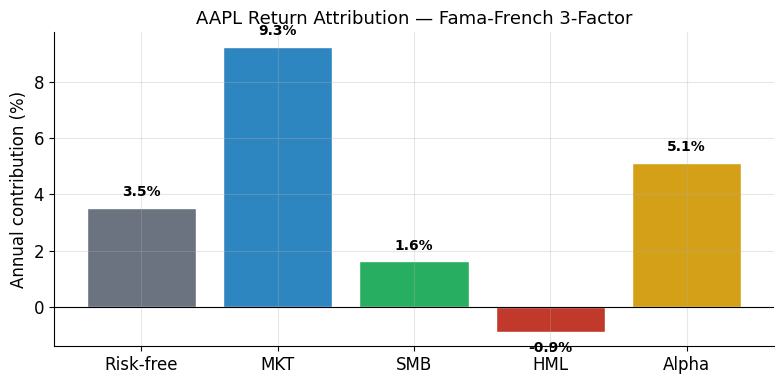

In [9]:
# Annualised factor premium estimates from our sample
mkt_premium = df['MKT'].mean() * 252
smb_premium = df['SMB'].mean() * 252
hml_premium = df['HML'].mean() * 252

# Attribution: how much does each factor contribute to AAPL's expected return?
contrib_mkt   = beta_mkt  * mkt_premium
contrib_smb   = beta_smb  * smb_premium
contrib_hml   = beta_hml  * hml_premium
contrib_alpha = alpha_ff3 * 252
rf_annual     = df['RF'].mean() * 252

total = rf_annual + contrib_mkt + contrib_smb + contrib_hml + contrib_alpha

print('AAPL Annual Return Attribution (FF3F):')
print(f'  Risk-free rate      : {rf_annual:+.2%}')
print(f'  MKT contribution    : {contrib_mkt:+.2%}  (β={beta_mkt:.3f} × {mkt_premium:.2%})')
print(f'  SMB contribution    : {contrib_smb:+.2%}  (s={beta_smb:.3f} × {smb_premium:.2%})')
print(f'  HML contribution    : {contrib_hml:+.2%}  (h={beta_hml:.3f} × {hml_premium:.2%})')
print(f'  Alpha               : {contrib_alpha:+.2%}')
print(f'  ─────────────────────────────────────')
print(f'  Total (predicted)   : {total:+.2%}')
print(f'  Actual mean return  : {aapl_ret.mean()*252:+.2%}')

# Bar chart of attribution
labels = ['Risk-free', 'MKT', 'SMB', 'HML', 'Alpha']
values = [rf_annual, contrib_mkt, contrib_smb, contrib_hml, contrib_alpha]
colors = ['#6B7280', '#2E86C1', '#27AE60', '#C0392B', '#D4A017']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, [v*100 for v in values], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.3 if val >= 0 else -0.8),
            f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Annual contribution (%)')
ax.set_title('AAPL Return Attribution — Fama-French 3-Factor', fontsize=13)
plt.tight_layout()
plt.show()


<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Factor Profile Comparison — Three Contrasting Securities</div>

**Comparing FF3F factor loadings across three very different securities.**

| Security | Style | β_MKT | β_SMB | β_HML | R² |
|----------|-------|-------|-------|-------|----|
| AAPL | Tech · Mega-cap Growth | ~+1.18 | ~−0.35 | ~−0.36 | ~0.67 |
| XOM  | Energy · Large-cap Value | ~+0.91 | ~−0.22 | ~+0.49 | ~0.61 |
| IWM  | Russell 2000 · Small-cap ETF | ~+0.97 | ~+0.86 | ~+0.21 | ~0.93 |

> **Run the cell below to compute live values — they may differ slightly from the slide.**

In [10]:
# ── Factor Profile Comparison: AAPL vs XOM vs IWM ──────────────────────
COMPARE_TICKERS = ['AAPL', 'XOM', 'IWM']

comp_results = {}
print('Downloading comparison tickers...')
for tkr in COMPARE_TICKERS:
    px = yf.download(tkr, start=START, end=END,
                     auto_adjust=True, progress=False)['Close'].squeeze()
    ret = px.pct_change().dropna()
    ret.index = ret.index.tz_localize(None)
    dft = ff3.join(ret.rename(tkr), how='inner').dropna()
    dft['ri_exc'] = dft[tkr] - dft['RF']
    X_t = sm.add_constant(dft[['MKT', 'SMB', 'HML']])
    r = sm.OLS(dft['ri_exc'], X_t).fit()
    comp_results[tkr] = {
        'α/yr':  r.params['const'] * 252,
        'β_MKT': r.params['MKT'],
        'β_SMB': r.params['SMB'],
        'β_HML': r.params['HML'],
        'R²':    r.rsquared,
        'p(α)':  r.pvalues['const'],
    }

comp_df = pd.DataFrame(comp_results).T
print('\nFF3F Factor Profile Comparison:')
print(comp_df.round(3).to_string())



FF3F Factor Profile Comparison:
       α/yr  β_MKT  β_SMB  β_HML     R²   p(α)
AAPL  0.051  1.164 -0.307 -0.208  0.576  0.530
XOM   0.135  0.773 -0.111  0.960  0.342  0.169
IWM  -0.017  1.006  0.914  0.287  0.978  0.254


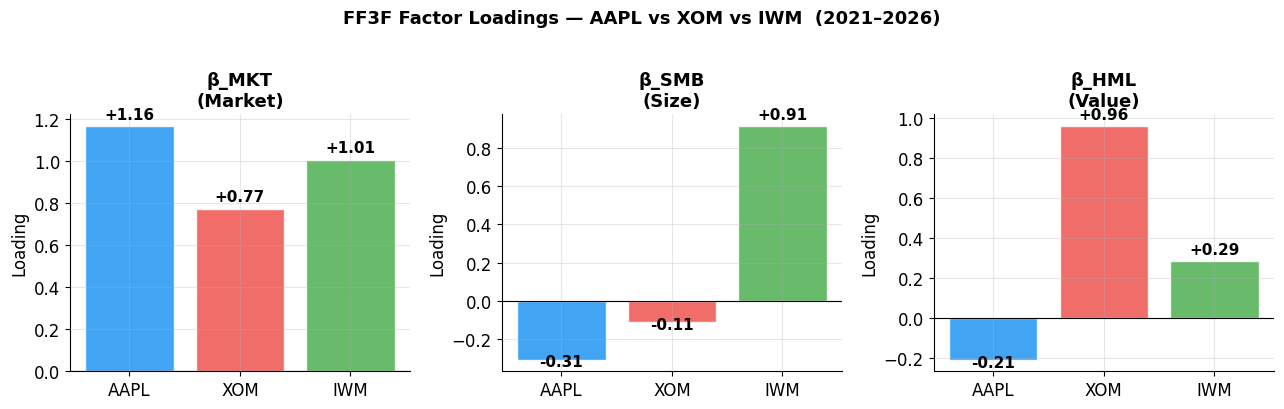


Key contrasts:
  HML: AAPL -0.208 vs XOM +0.960  — same size tier, opposite value/growth style
  SMB: IWM +0.914  — IWM IS the small-cap universe, β_SMB near +1


In [11]:
# ── Factor loading comparison chart ─────────────────────────────────────
factors = ['β_MKT', 'β_SMB', 'β_HML']
factor_labels = ['β_MKT\n(Market)', 'β_SMB\n(Size)', 'β_HML\n(Value)']
x = range(len(COMPARE_TICKERS))
palette = ['#2196F3', '#EF5350', '#4CAF50']  # blue=AAPL, red=XOM, green=IWM

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
for ax, fac, flabel in zip(axes, factors, factor_labels):
    vals = [comp_df.loc[t, fac] for t in COMPARE_TICKERS]
    bar_colors = [palette[i] for i in range(len(COMPARE_TICKERS))]
    bars = ax.bar(COMPARE_TICKERS, vals, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(flabel, fontsize=13, fontweight='bold')
    ax.set_ylabel('Loading')
    for bar, v in zip(bars, vals):
        offset = 0.02 if v >= 0 else -0.05
        ax.text(bar.get_x() + bar.get_width()/2, v + offset,
                f'{v:+.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.suptitle('FF3F Factor Loadings — AAPL vs XOM vs IWM  (2021–2026)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Key insight summary
aapl_hml = comp_df.loc['AAPL', 'β_HML']
xom_hml  = comp_df.loc['XOM',  'β_HML']
iwm_smb  = comp_df.loc['IWM',  'β_SMB']
print(f'\nKey contrasts:')
print(f'  HML: AAPL {aapl_hml:+.3f} vs XOM {xom_hml:+.3f}  '
      f'— same size tier, opposite value/growth style')
print(f'  SMB: IWM {iwm_smb:+.3f}  '
      f'— IWM IS the small-cap universe, β_SMB near +1')


<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">What Is Ollama? — A Free, Local AI Model Runtime</div>

**Ollama is a free tool that lets you run AI language models entirely on your own computer** — no internet connection required after setup, no API key, no monthly bill, and no data ever leaves your machine. Think of it as *Docker for AI models*: a single application that downloads pre-packaged open-weight models from a central catalogue and runs them locally for you.

### Why this only became practical recently
Frontier models like GPT-4 or Claude Sonnet have **hundreds of billions of parameters** and cannot fit on a laptop. Over the last two years, researchers produced much smaller models (1–8 B parameters) that are good enough for many everyday tasks — summarisation, classification, simple Q&A. Combined with **4-bit quantisation** (compressing each weight from 16 bits to 4 bits), these models now fit on a 16 GB laptop. Ollama is the easiest path to running them.

### The four pieces that make Ollama work
1. **Model catalogue (online)** — central library at ollama.com hosting hundreds of open-weight models: Llama 3 (Meta), Phi-3 (Microsoft), Mistral, Gemma (Google), Qwen (Alibaba). Each model is identified by a `name:size` tag, e.g. `llama3.1:8b`.
2. **Local model cache (your hard drive)** — when you `pull` a model, Ollama downloads it once into `~/.ollama/models/`. After that the model is yours forever, even offline. Typical small model: 1–4 GB.
3. **Ollama server (background process)** — a quietly-running program that loads model weights into RAM, runs inference on your CPU or GPU, and listens for requests on `localhost:11434`. Auto-started on Mac/Linux/Windows.
4. **Clients** — three ways to send prompts: (a) interactive terminal via `ollama run llama3.1:8b`, (b) Python via `import ollama`, (c) any tool that speaks the OpenAI HTTP API format, pointed at `localhost:11434/v1`.

### What happens when you ask Ollama a question from Python
```
Your script  ──1. send prompt──►  Ollama server  ──2. load model──►  Local cache
                                       │                                 │
                                       └◄────── 3. run inference ────────┘
                                       │
Your script  ◄──4. text answer ────────┘
```
The entire round trip happens on your machine. **Nothing crosses your network.** Disconnect your Wi-Fi and it still works.

### Why a finance student should care
- **Privacy** — earnings transcripts, internal research, client portfolios often *cannot* legally be sent to a hosted API. Local inference solves this cleanly.
- **Cost** — at 500 stocks × 12 months × multiple queries each, even Haiku adds up. Local LLMs are free at the margin.
- **Reproducibility** — a hosted model can change underneath you with no notice. The file on your disk does not.

### What it cannot do
Even an 8 B-parameter Llama 3.1 is noticeably weaker than Claude Sonnet at multi-step reasoning, structured output, and long-document understanding. Local LLMs and cloud APIs are **complementary, not substitutes** — choose the right tier for the task.

<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> <b>Live demo trick.</b> Open a terminal, type <code>ollama run llama3.1:8b</code>, ask it a finance question, and watch it answer in front of the class. Total elapsed time from install to first answer: about 5 minutes. This is the most concrete way to make 'local LLM' tangible.</div>